# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [42]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [43]:
# cargar archivos

plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

for nombre, df in [('plans', plans), ('users', users), ('usage', usage)]:
    print(f"--- {nombre} ---")
    print("Filas:", len(df))
    print("Duplicados:", df.duplicated().sum())
    resumen = pd.DataFrame({
        'filas_nulas': df.isna().sum(),
        'porcentaje': (df.isna().mean() * 100).round(2)
    })
    print(resumen[resumen['filas_nulas'] > 0])
    print()

print(users['churn_date'].dropna().head(10))
print(usage['date'].head(10))

users['city'] = users['city'].fillna('Desconocida')
users['churn_date'] = pd.to_datetime(users['churn_date'], errors='coerce')
usage = usage.dropna(subset=['date']).copy()
usage['date'] = pd.to_datetime(usage['date'])
usage['duration'] = usage['duration'].fillna(0)
usage['length'] = usage['length'].fillna(0)
    
for nombre, df in [('plans', plans), ('users', users), ('usage', usage)]:
    print(f"--- {nombre} ---")
    print("Filas:", len(df))
    print(df.isna().sum())

    print()





--- plans ---
Filas: 2
Duplicados: 0
Empty DataFrame
Columns: [filas_nulas, porcentaje]
Index: []

--- users ---
Filas: 4000
Duplicados: 0
            filas_nulas  porcentaje
city                469       11.72
churn_date         3534       88.35

--- usage ---
Filas: 40000
Duplicados: 0
          filas_nulas  porcentaje
date               50        0.12
duration        22076       55.19
length          17896       44.74

32    1,71832E+18
38     1,7261E+18
42    1,72169E+18
44     1,7312E+18
47    1,72843E+18
54    1,72351E+18
56    1,72187E+18
69    1,72264E+18
73    1,72817E+18
76    1,73405E+18
Name: churn_date, dtype: object
0    2024-01-01 00:00:00.000000000
1    2024-01-01 00:06:30.969774244
2    2024-01-01 00:13:01.939548488
3    2024-01-01 00:19:32.909322733
4    2024-01-01 00:26:03.879096977
5    2024-01-01 00:32:34.848871221
6    2024-01-01 00:39:05.818645466
7    2024-01-01 00:45:36.788419710
8    2024-01-01 00:52:07.758193954
9    2024-01-01 00:58:38.727968199
Name: date, 

In [44]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,0.0
1,2,11458,text,2024-01-01 00:06:30.969774244,0.00,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,0.00,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,0.0
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,0.0


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [45]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (39950, 6)


In [46]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [47]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4000 non-null   int64         
 1   first_name  4000 non-null   object        
 2   last_name   4000 non-null   object        
 3   age         4000 non-null   int64         
 4   city        4000 non-null   object        
 5   reg_date    4000 non-null   object        
 6   plan        4000 non-null   object        
 7   churn_date  0 non-null      datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 250.1+ KB


In [48]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 39950 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        39950 non-null  int64         
 1   user_id   39950 non-null  int64         
 2   type      39950 non-null  object        
 3   date      39950 non-null  datetime64[ns]
 4   duration  39950 non-null  float64       
 5   length    39950 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 2.1+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [49]:
# cantidad de nulos para users
print(pd.isna(users).sum())

user_id          0
first_name       0
last_name        0
age              0
city             0
reg_date         0
plan             0
churn_date    4000
dtype: int64


In [50]:
print(pd.isna(usage).sum())

id          0
user_id     0
type        0
date        0
duration    0
length      0
dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  = la columna churn_date tiene 4000 valores nulos.
- Indica qué harías: ¿imputar, eliminar, ignorar? = Se deben imputar.
  
- En la columna users tenemnos un gran porcentaje de nulos, lo que tendriamos que hacer el eliminarlos.
- En la columna usage hay un 40% porcento aproximado de nulos seria necesario investigarlos para saber si ejecutamos a eliminiarlos.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [51]:
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
- La columna `age` ...Veo que el promedio de la edad de las personas es de 33 años, pero por lo contrario se detecta un error con la edad minima con -999 algo que no es común.
  

In [52]:
usage.describe()

,id,user_id,duration,length
count,39950.000000,39950.000000,39950.000000,39950.000000
mean,20000.310438,12002.428761,2.331219,28.813467
std,11548.148869,1157.421395,5.262079,49.446259
min,1.000000,10000.000000,0.000000,0.000000
25%,10000.250000,10995.250000,0.000000,0.000000
50%,20001.500000,12013.000000,0.000000,24.000000
75%,30001.750000,13005.000000,2.940000,53.000000
max,40000.000000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas ...

In [53]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users["city"].describe())
users["plan"].describe()

count       4000
unique         8
top       Bogotá
freq         808
Name: city, dtype: object


count       4000
unique         2
top       Basico
freq        2595
Name: plan, dtype: object

- La columna `city` ...
- La columna `plan` ...

In [54]:
# explorar columna categórica de usage
print(usage["type"].describe())

count     39950
unique        2
top        text
freq      22068
Name: type, dtype: object


- La columna `type` ...


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [55]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'])

In [56]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])

In [57]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.unique())

[2022 2026 2023 2024]


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

In [58]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.unique())

[2024]


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.
OK vemos que en (users)maneja estadisticas de los años 2022, 2023, 2024 y 2026.
Y de (usage) solo se ven estadisticas del año 2024.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [59]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [60]:
# Reemplazar ? por NA en city
users["city"] = users["city"].replace("?", pd.NA )

# Verificar cambios
users["city"].isna().sum()

96

In [61]:
# Marcar fechas futuras como NA para reg_date
users["reg_date"] > pd.Timestamp.now()

# Verificar cambios
users["reg_date"] = pd.to_datetime(users["reg_date"])

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [62]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby("type")["duration"].apply(lambda x: x.isna().sum())

type
call    0
text    0
Name: duration, dtype: int64

In [63]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby("type")["length"].apply(lambda x: x.isna().sum())

type
call    0
text    0
Name: length, dtype: int64

In [64]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id")["length"].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,length
0,10000,258.0
1,10001,226.0
2,10002,225.0


In [65]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={"length": "total_length"})
# observar resultado
usage_agg.head(3)

,user_id,total_length
0,10000,258.0
1,10001,226.0
2,10002,225.0


In [66]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on="user_id")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,total_length
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT,258.0
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaT,226.0
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT,225.0
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaT,530.0
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaT,229.0


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [67]:
# Resumen estadístico de las columnas numéricas
user_profile[["total_length", "age"]].describe()

,total_length,age
count,3999.000000,3999.000000
mean,287.846462,48.124531
std,180.893331,17.692032
min,0.000000,18.000000
25%,183.000000,33.000000
50%,268.000000,47.000000
75%,361.000000,63.000000
max,2028.000000,79.000000


In [68]:
# Distribución porcentual del tipo de plan
users["plan"].value_counts(normalize=True)

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

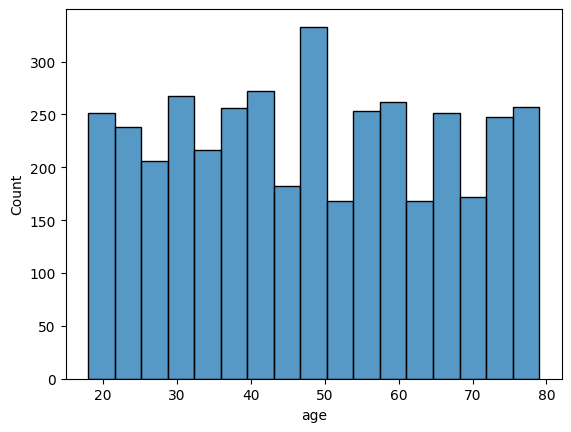

In [69]:
# Histograma para visualizar la edad (age)
sns.histplot(users["age"])
plt.show()

💡Insights: 
- Distribución ...

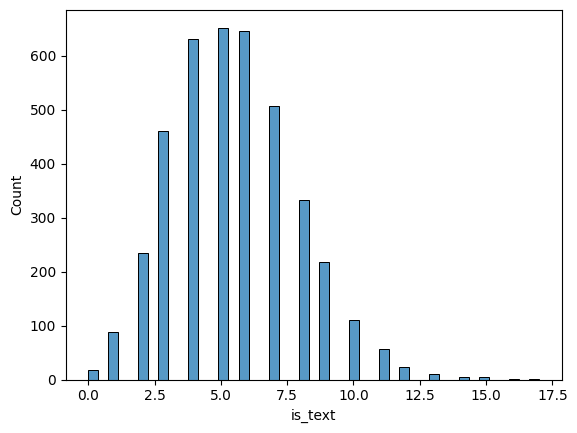

In [70]:
# Histograma para visualizar la cant_mensajes
cant_mensajes = usage.groupby("user_id")["is_text"].sum().reset_index() 
sns.histplot(cant_mensajes["is_text"])
plt.show()
#usage.head()
#usage.groupby('type')["type"].count()

💡Insights: 
- En este histograma se ve un gran numero de usuarios con muy poca cantidad de mensajes, y un pequeño grupo de usuarios usan muchos mensajes.

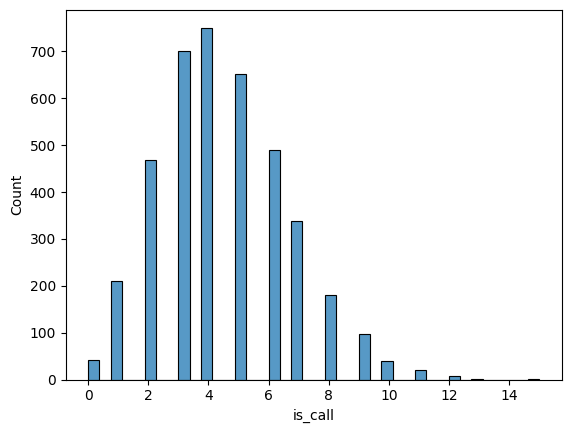

In [71]:
# Histograma para visualizar la cant_llamadas
cant_llamadas = usage.groupby("user_id")["is_call"].sum().reset_index() 
sns.histplot(cant_llamadas["is_call"])
plt.show()

💡Insights: 
- En este histograma se ve un gran numero de usuarios con muy poca cantidad de llamadas, y un pequeño grupo de usuarios usan muchas llamadas.

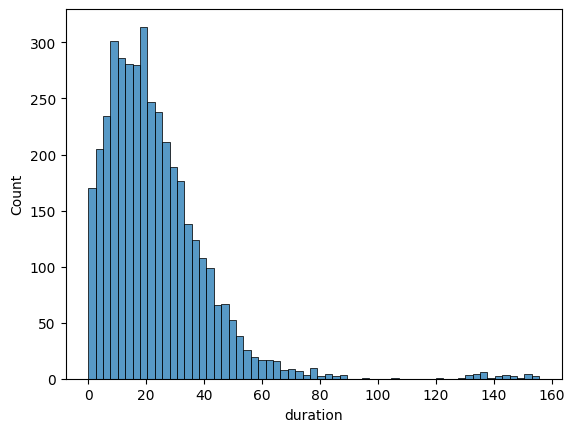

In [72]:
# Histograma para visualizar la cant_minutos_llamada
total_minutos_llamada = usage.groupby("user_id")["duration"].sum().reset_index() 
sns.histplot(total_minutos_llamada["duration"])
plt.show()

💡Insights: 
- En este histograma vemos que la mayoria de los usurios usan pocos minutos en sus llamadas y por lo contrario son muy pocos los usuarios que que tienen una duración larga de llamadas.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

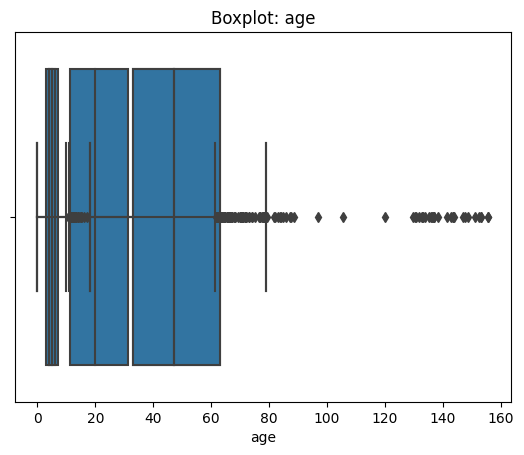

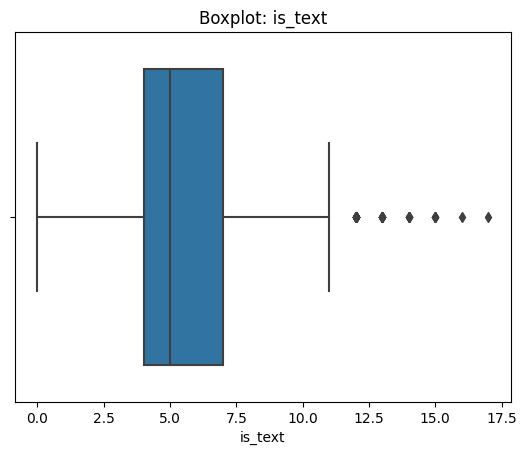

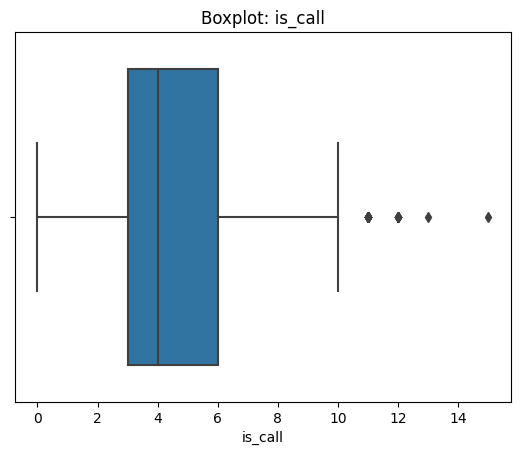

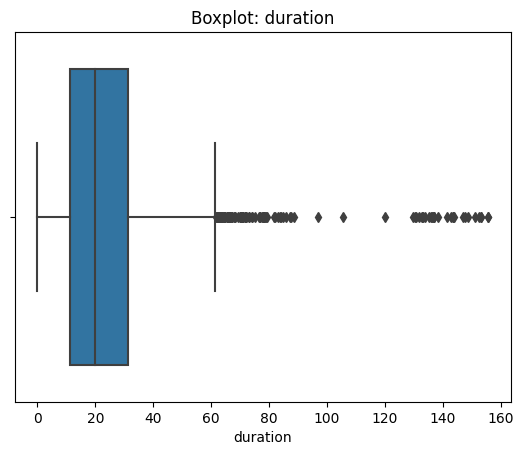

In [73]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'total_minutos_llamada']

    
dataframes = [user_profile, cant_mensajes, cant_llamadas, total_minutos_llamada]
columnas = ("age", "is_text", "is_call", "duration")
zip(dataframes,columnas )

for df, col in zip(dataframes,columnas):
    sns.boxplot(x=df[col])
    
sns.boxplot(x=user_profile["age"])
plt.title(f'Boxplot: {"age"}')
plt.xlabel("age")
plt.show()    

sns.boxplot(x=cant_mensajes["is_text"])
plt.title(f'Boxplot: {"is_text"}')
plt.xlabel("is_text")
plt.show()

sns.boxplot(x=cant_llamadas["is_call"])
plt.title(f'Boxplot: {"is_call"}')
plt.xlabel("is_call")
plt.show()

sns.boxplot(x=total_minutos_llamada["duration"])
plt.title(f'Boxplot: {"duration"}')
plt.xlabel("duration")
plt.show()


💡Insights: 
- Age: ...(presenta o no outliers) La mayoría de los usuarios tiene edades dentro de un rango normal, pero hay varios outliers por encima del bigote superior, es decir, usuarios con edades bastante más altas que el resto.
- cant_mensajes: ...En is text los mensajes estan en un rango moderado con muy pocos outliers por encima del bigote superior.
- cant_llamadas: ...En is call las llamadas tienen el mismo comportamiento que los mensajes con un rango moderado y poca cantidad de outliers por encima del bigote superior.
- cant_minutos_llamada: ... vemos que en gran mayoría de las llamadas duran poco tiempo lo que nos dice que hay pocos minutos concentrados abajo y tan solo unas pocas llamadas duran mucho tiempo lo notamos con los outliers por encima de los bigotes.

In [74]:
# Calcular límites con el método IQR
q1_duration = total_minutos_llamada["duration"].quantile(0.25)
q3_duration = total_minutos_llamada["duration"].quantile(0.75)
IQR = q3_duration - q1_duration
lower = q1_duration - 1.5 * IQR
upper = q3_duration + 1.5 * IQR

q1_is_text = cant_mensajes["is_text"].quantile(0.25)
q3_is_text = cant_mensajes["is_text"].quantile(0.75)
IQR1 = q3_is_text - q1_is_text
lower1 = q1_is_text - 1.5 * IQR1
upper1 = q3_is_text + 1.5 * IQR1

q1_is_call = cant_llamadas["is_call"].quantile(0.25)
q3_is_call = cant_llamadas["is_call"].quantile(0.75)
IQR2 = q3_is_call - q1_is_call
lower2 = q1_is_call - 1.5 * IQR2
upper2 = q3_is_call + 1.5 * IQR2



In [75]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
(total_minutos_llamada["duration"] > upper).sum()
(cant_mensajes["is_text"] > upper1).sum()
(cant_llamadas["is_call"] > upper2).sum()

(total_minutos_llamada["duration"] < lower).sum()
(cant_mensajes["is_text"] < lower1).sum()
(cant_llamadas["is_call"] < lower2).sum()

0

💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? = No se detectan outliers por debajo del limite inferior, los outliers relevantes estan inclinados en upper.
- cant_llamadas: mantener o no outliers, porqué? = No se detectan outliers por debajo del limite inferior, los outliers relevantes estan inclinados en upper.
- cant_minutos_llamada: mantener o no outliers, porqué? = No se detectan outliers por debajo del limite inferior, los outliers relevantes estan inclinados en upper.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [76]:
# Crear columna grupo_uso
user_profile = user_profile.merge(cant_mensajes, on='user_id', how='left')
user_profile = user_profile.merge(cant_llamadas, on='user_id', how='left')
user_profile = user_profile.merge(total_minutos_llamada, on='user_id', how='left')
user_profile.columns


Index(['user_id', 'first_name', 'last_name', 'age', 'city', 'reg_date', 'plan',
       'churn_date', 'total_length', 'is_text', 'is_call', 'duration'],
      dtype='object')

In [77]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,total_length,is_text,is_call,duration
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT,258.0,7,3,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaT,226.0,5,10,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT,225.0,5,2,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaT,530.0,11,3,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaT,229.0,4,3,8.01


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [78]:
# Crear columna grupo_edad

def grupo_edad (age):
    if age < 30:
       return "Joven"
    elif age < 60:
       return "Adulto"
    else:
       return "Adulto Mayor"

user_profile["grupo_edad"] = user_profile["age"].apply(grupo_edad)

def grupo_uso(fila):
    llamadas = fila['is_call']
    mensajes = fila['is_text']

    if llamadas < 5 and mensajes < 5:
        return 'Bajo uso'
    elif llamadas < 10 and mensajes < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(grupo_uso, axis=1)

print(user_profile['grupo_uso'].value_counts())
user_profile.head()



Uso medio    2941
Bajo uso      780
Alto uso      278
Name: grupo_uso, dtype: int64


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,total_length,is_text,is_call,duration,grupo_edad,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT,258.0,7,3,23.70,Adulto,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaT,226.0,5,10,33.18,Adulto,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT,225.0,5,2,10.74,Adulto,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaT,530.0,11,3,8.99,Adulto Mayor,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaT,229.0,4,3,8.01,Adulto Mayor,Bajo uso


In [79]:
# verificar cambios
user_profile[["age", "grupo_edad"]].head()

,age,grupo_edad
0,38.0,Adulto
1,53.0,Adulto
2,57.0,Adulto
3,69.0,Adulto Mayor
4,63.0,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

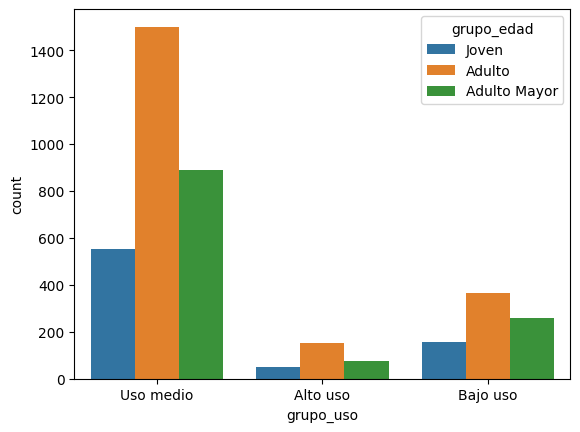

In [80]:
# Visualización de los segmentos por uso


sns.countplot(
    data=user_profile,
    x='grupo_uso',
    hue='grupo_edad',
    hue_order=['Joven', 'Adulto', 'Adulto Mayor'])

plt.show()



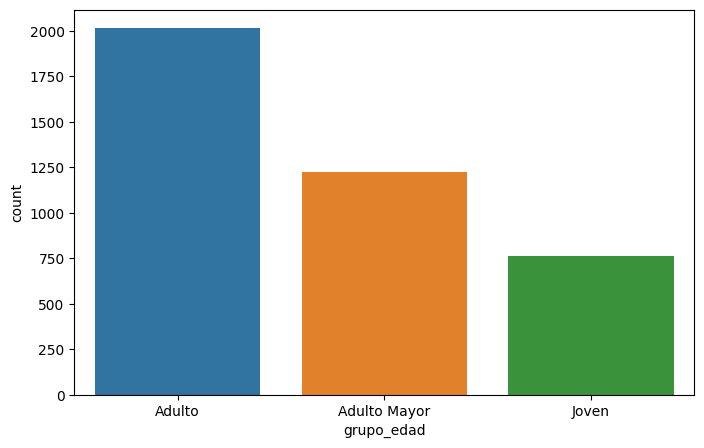

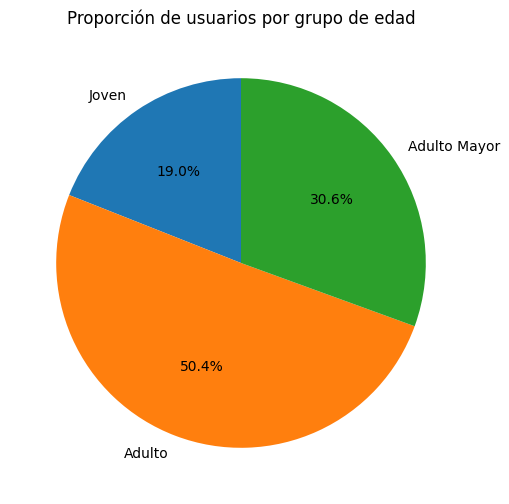

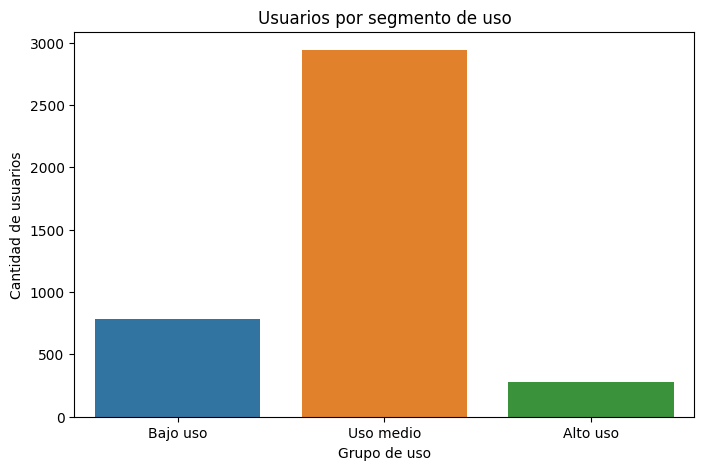

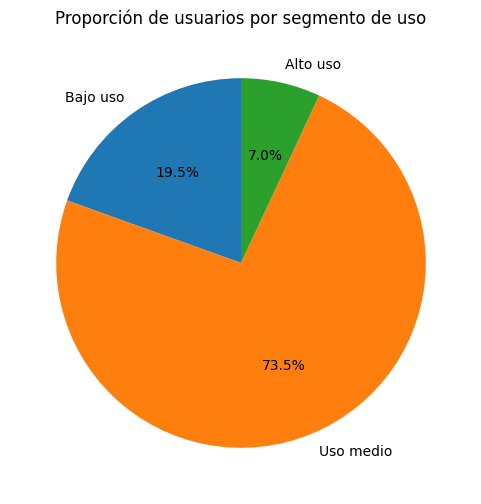

In [81]:
# Visualización de los segmentos por edad

orden_edad = ['Joven', 'Adulto', 'Adulto Mayor']

plt.figure(figsize=(8, 5))
sns.countplot(data=user_profile, x='grupo_edad')
plt.show()

plt.figure(figsize=(6, 6))
user_profile['grupo_edad'].value_counts().reindex(orden_edad).plot(
    kind='pie', autopct='%1.1f%%', startangle=90
)
plt.title('Proporción de usuarios por grupo de edad')
plt.ylabel('')
plt.show()


orden_uso = ['Bajo uso', 'Uso medio', 'Alto uso']

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=user_profile, x='grupo_uso', order=orden_uso)
plt.title('Usuarios por segmento de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

plt.figure(figsize=(6, 6))
user_profile['grupo_uso'].value_counts().reindex(orden_uso).plot(
    kind='pie', autopct='%1.1f%%', startangle=90
)
plt.title('Proporción de usuarios por segmento de uso')
plt.ylabel('')
plt.show()




---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
  OK, Originalmente los datos no presentaban filas duplicadas, pero sí valores nulos. En users, la columna city tenía 469 nulos (11.72 %) y churn_date 3534    (88.35 %), este último esperado porque corresponde a usuarios que no cancelaron. En usage, date tenía 50 nulos (0.12 %), duration 22076 (55.19 %) y length      17896 (44.74 %); estos dos últimos son nulos estructurales, ya que duration aplica solo a llamadas y length solo a mensajes. La tabla plans no tenía nulos.       Se trataron rellenando city con "Desconocida", eliminando las filas sin date y rellenando con 0 los valores de duration y length.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
Ok primero se identificaron 3 grupos de edades BAJO, MEDIO, ALTO. El grupo más numeroso de clientes son los adultos. El grupo que más genero uso fueron  los adultos con un 73.5% y los que menos generaron uso fueron Adulto mayor con un 7.0%.


- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

= El segmento más valioso para ConnectaTel es el grupo de ADULTOS ya que son los que más tienen uso del producto y por mayor tiempo y por ende tienen menos cancelación de suscripción. 

 
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

= La variable de duración de llamadas es la que más outliers muestra fuera de los bigotes. Están todos por arriba del bigote superior, es decir, son llamadas con una duración inusualmente larga comparada con la mayoría de los clientes. Lo que implica es que son clientes de alto consumo de voz: usan muchísimo el servicio de llamadas, lo cual podría ser una oportunidad para ofrecerles un plan con más minutos (o ilimitado) si no lo tienen, generando más ingresos.

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
  
= Para el segmento de Alto uso se podría ofrecer un plan con minutos ilimitados o más generoso, para el Bajo uso seria ofrecer una oferta de retención o un plan más económico ajustado a su consumo real y para el USo medio lo cual es el grupo más grande un plan intermedio entre Básico y Premium que les quede mejor, ya que son la mayoría.


✍️ **Escribe aquí tu análisis ejecutivo:**
= Perfecto. Para el grupo de adultos ofrecería un plan de fidelidad para retenerlos ya que es el más uso de servicio con un (73.5%) y asi protegería la mayor parte de los ingresos. Y pensaría en un plan de descuentos para los jovenes y asi buscar aumentar su participación y convertirlos en suscriptores activos a futuro.
Adicional el segmento de alto consumo de llamadas (outliers de duración), que podría necesitar un plan con más minutos.
 


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Los datos nulos que se encontraron como por ejemplo city (469) con un 11.72%  y churn_date (3534) 88.35%. Gracias a esto se logra una limpieza para que usage quede con 39950 filas y sin nulos.

🔍 **Segmentos por Edad**
- Se crearon 3 grupos de edades, menores de 30 y se denominan JOVEN, entre 30 a 59 años se denominan ADULTO y si por lo contrario no cumple con estas condiciones se denominan ADULTO MAYOR.


📊 **Segmentos por Nivel de Uso**
- Para el segmento uso vemos que el grupo adultos fue el grupo que más participo y el uso medio fue el de mayor trafico con un 73.5%.


➡️ Esto sugiere que ...Para el grupo de adultos ofrecería un plan de fidelidad para retenerlos ya que es el más uso de servicio con un (73.5%) y asi protegería la mayor parte de los ingresos. Y pensaría en un plan de descuentos para los jovenes y asi buscar aumentar su participación y convertirlos en suscriptores activos a futuro. Adicional el segmento de alto consumo de llamadas (outliers de duración), que podría necesitar un plan con más minutos.


💡 **Recomendaciones**
- Para el grupo de adultos ofrecería un plan de fidelidad para retenerlos ya que es el más uso de servicio con un (73.5%) y asi protegería la mayor parte de los ingresos. Y pensaría en un plan de descuentos para los jovenes y asi buscar aumentar su participación y convertirlos en suscriptores activos a futuro. Adicional el segmento de alto consumo de llamadas (outliers de duración), que podría necesitar un plan con más minutos.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`

## 